<a href="https://colab.research.google.com/github/shivainlabs/Machine-Learning/blob/main/Supervised%20Learning/Linear%20Regression/Regression_Matrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day48-simple-linear-regression/placement.csv"

df = pd.read_csv(url)

In [56]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [57]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

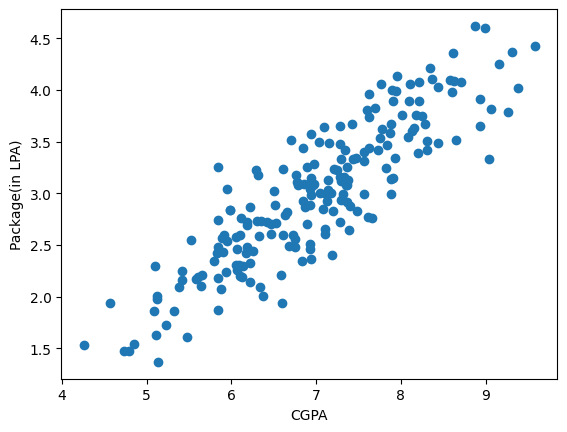

In [59]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package(in LPA)")
plt.show()

In [60]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_predict = lr.predict(X_train)

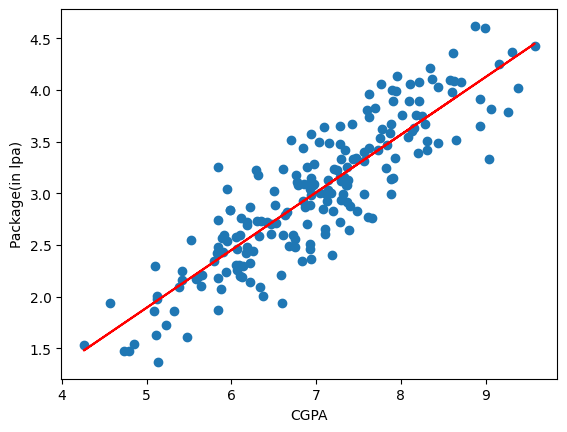

In [61]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,y_predict,color='red')
plt.xlabel("CGPA")
plt.ylabel("Package(in lpa)")
plt.show()

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
y_pred = lr.predict(X_test)

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2",r2_score(y_test,y_pred))

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 0.780730147510384


In [64]:
# Adjusted R2 Score
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
k = X_test.shape[1]

adjusted_r2 = 1-(((1-r2)*(n-1))/(n-k-1))
print("R2",r2_score(y_test,y_pred))
print("Adjusted R2",adjusted_r2)

R2 0.780730147510384
Adjusted R2 0.7749598882343415


## Testing Adjusted R2 Score

Adding random feature

In [65]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(df.shape[0])

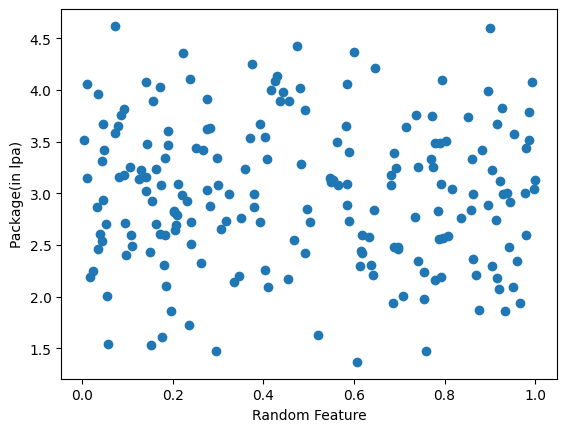

In [66]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel("Random Feature")
plt.ylabel("Package(in lpa)")
plt.show()

In [67]:
X = new_df1.loc[:,['cgpa','random_feature']]
y = new_df1.loc[:,['package']]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [68]:
y_pred = lr.predict(X_test)

print(r2_score(y_test,y_pred))

0.7810455965694775


In [69]:
y_pred = lr.predict(X_test)
# Adjusted R2 Score
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
k = X_test.shape[1]

adjusted_r2 = 1-(((1-r2)*(n-1))/(n-k-1))
print("R2",r2_score(y_test,y_pred))
print("Adjusted R2",adjusted_r2)

R2 0.7810455965694775
Adjusted R2 0.7692102234110708


### Now Adding relevant Feature

In [70]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,df.shape[0])/10)
new_df2 = new_df2[['cgpa','iq','package']]

,cgpa,iq,package
0,6.89,4.06,3.26
1,5.12,0.78,1.98
2,7.82,3.45,3.25
3,7.42,3.37,3.67
4,6.94,3.27,3.57
...,...,...,...
195,6.93,2.46,2.46
196,5.89,1.37,2.57
197,7.21,3.84,3.24
198,7.63,2.76,3.96


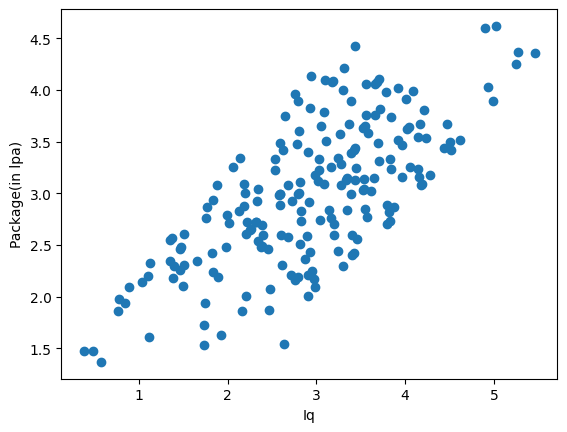

In [73]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel("Iq")
plt.ylabel("Package(in lpa)")
plt.show()

In [74]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [75]:
y_pred = lr.predict(X_test)
# Adjusted R2 Score
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
k = X_test.shape[1]

adjusted_r2 = 1-(((1-r2)*(n-1))/(n-k-1))
print("R2",r2_score(y_test,y_pred))
print("Adjusted R2",adjusted_r2)

R2 0.8118694278343279
Adjusted R2 0.8017002077172646
